# ¿Cuál es la mejor tarifa?



Explicación del proyecto:

Soy analista de datos de una empresa de telecomunicaciones y quieren evaluar cuál de sus dos planes de prepago genera más ingresos para así poder distribuir mejor el presupuesto destinado a la publicidad. Mi trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos. Me están dando una pequeña muestra de 500 usuarios para poder evaluar a toda su población de clientes. Esto significa que tendré que hacer inferencias sobre toda la población a partir de esta muestra.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import numpy as np 
import math as mt
from matplotlib import pyplot as plt
from scipy import stats as st




## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_users = pd.read_csv('megaline_users.csv')
df_calls = pd.read_csv('megaline_calls.csv')
df_messages = pd.read_csv('megaline_messages.csv')
df_internet = pd.read_csv('megaline_internet.csv')
df_plans = pd.read_csv('megaline_plans.csv')



## Preparar los datos

### Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
print(df_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


"No hay nada que hacer en este dataframe. No hay valores nulos ni duplicados, además los tipos de datos van acorde a los valores y sus significados en las columnas. Tampoco parece haber datos que enriquecer a los datos"

### Usuarios/as

In [5]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprime una muestra de datos para usuarios

print(df_users.head())


   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


"El plan va a ser primero ver valores duplicados y luego los valores ausentes en la columna churn_date los vamos a dejar y más bien vamos a hacer un cambio de tipo de dato hacia datetime. Después va a ser cambiar el tipo de dato de la columna reg_date por un tipo datetime"

#### Corregir los datos

In [ ]:
#valores duplicados
print("Numero de filas duplicadas:", df_users.duplicated().sum())
print()
print()
print("Numero de id_usuarios duplicados:", df_users["user_id"].duplicated().sum())
print("Numero de userlast_name duplicados:", df_users[["user_id", "last_name"]].duplicated().sum())


Numero de filas duplicadas: 0


Numero de id_usuarios duplicados: 0
Numero de userlast_name duplicados: 0


In [8]:
#convertir a tipos de dato datetime las columnas reg_date y churn_date y 
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])


#### Enriquecer los datos

In [ ]:
#agregar columna 'dias_permanencia'
df_users['dias_permanencia'] = (df_users['churn_date'] - df_users['reg_date']).dt.days.astype('Int64')


print(df_users.info())
print()
print()
print(df_users.sample(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           500 non-null    int64         
 1   first_name        500 non-null    object        
 2   last_name         500 non-null    object        
 3   age               500 non-null    int64         
 4   city              500 non-null    object        
 5   reg_date          500 non-null    datetime64[ns]
 6   plan              500 non-null    object        
 7   churn_date        34 non-null     datetime64[ns]
 8   dias_permanencia  34 non-null     Int64         
dtypes: Int64(1), datetime64[ns](2), int64(2), object(4)
memory usage: 35.8+ KB
None


     user_id first_name  last_name  age  \
251     1251     Tifany      Mcgee   45   
146     1146       Loma     Mcneil   42   
223     1223   Patience     Wilson   37   
458     1458     Joella      Munoz   32   


### Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprime una muestra de datos para las llamadas

print(df_calls.head(15))


          id  user_id   call_date  duration
0    1000_93     1000  2018-12-27      8.52
1   1000_145     1000  2018-12-27     13.66
2   1000_247     1000  2018-12-27     14.48
3   1000_309     1000  2018-12-28      5.76
4   1000_380     1000  2018-12-30      4.22
5   1000_388     1000  2018-12-31      2.20
6   1000_510     1000  2018-12-27      5.75
7   1000_521     1000  2018-12-28     14.18
8   1000_530     1000  2018-12-28      5.77
9   1000_544     1000  2018-12-26      4.40
10  1000_693     1000  2018-12-31      4.31
11  1000_705     1000  2018-12-31     12.78
12  1000_735     1000  2018-12-29      1.70
13  1000_778     1000  2018-12-28      3.29
14  1000_826     1000  2018-12-26      9.96


"No tenemos valores nulos en ninguna columna, así que vamos a revisar si hay filas repetidas y después cambiar los tipos de datos de la columna call_date a datetime"

#### Corregir los datos

In [ ]:
#filas duplicadas.

print("Numero de filas duplicadas:", df_calls.duplicated().sum())


Numero de filas duplicadas: 0


In [ ]:
#redondear la duracion de las llamadas hacia el minuto proximo mas alto

df_calls['duration'] = np.ceil(df_calls['duration'])
print(df_calls. sample(20))


              id  user_id   call_date  duration
74263   1263_247     1263  2018-12-11       4.0
136225   1494_67     1494  2018-07-19       2.0
62294   1223_475     1223  2018-11-04      14.0
88078   1324_119     1324  2018-07-20      18.0
70338   1251_349     1251  2018-09-12      16.0
129423  1465_864     1465  2018-12-14      10.0
89469   1326_120     1326  2018-09-22       8.0
4967    1022_233     1022  2018-05-29       3.0
130769  1470_218     1470  2018-08-16       4.0
56792   1203_183     1203  2018-10-05       2.0
123248  1434_603     1434  2018-07-14       2.0
69500   1249_375     1249  2018-06-01       7.0
38324   1144_214     1144  2018-11-10       3.0
96093   1341_108     1341  2018-11-24       0.0
98001   1352_221     1352  2018-12-05       0.0
136607   1495_32     1495  2018-09-16       6.0
26593   1100_150     1100  2018-08-18      14.0
42354   1155_326     1155  2018-09-26       9.0
110350  1389_426     1389  2018-08-31      17.0
102773  1364_438     1364  2018-09-30   

In [ ]:
#cambiar a datetime la columna call_date
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
print(df_calls.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
None


### Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes

print(df_messages.head(15))


          id  user_id message_date
0   1000_125     1000   2018-12-27
1   1000_160     1000   2018-12-31
2   1000_223     1000   2018-12-31
3   1000_251     1000   2018-12-27
4   1000_255     1000   2018-12-26
5   1000_346     1000   2018-12-29
6   1000_386     1000   2018-12-30
7   1000_413     1000   2018-12-31
8   1000_502     1000   2018-12-27
9   1000_525     1000   2018-12-28
10  1000_567     1000   2018-12-25
11    1001_1     1001   2018-11-14
12    1001_2     1001   2018-08-17
13    1001_5     1001   2018-12-05
14    1001_7     1001   2018-11-28


"No hay datos nulos. Revisaremos si hay filas enteras duplicadas y cambiaremos el tipo de dato de la columna message_date a tipo datetime"

#### Corregir los datos

In [ ]:
#filas duplicadas.
print("Numero de filas duplicadas:", df_messages.duplicated().sum())


Numero de filas duplicadas: 0


In [ ]:
#cambiar a datetime la columna message_date
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
print(df_messages.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
None


### Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(df_internet.head(15))


          id  user_id session_date  mb_used
0    1000_13     1000   2018-12-29    89.86
1   1000_204     1000   2018-12-31     0.00
2   1000_379     1000   2018-12-28   660.40
3   1000_413     1000   2018-12-26   270.99
4   1000_442     1000   2018-12-27   880.22
5     1001_0     1001   2018-08-24   284.68
6     1001_3     1001   2018-12-09   656.04
7     1001_4     1001   2018-11-04    16.97
8    1001_10     1001   2018-11-27   135.18
9    1001_15     1001   2018-12-13   761.92
10   1001_16     1001   2018-10-28   501.53
11   1001_17     1001   2018-09-05   727.29
12   1001_24     1001   2018-09-05   622.03
13   1001_25     1001   2018-10-14   310.43
14   1001_26     1001   2018-09-17     0.00


"No hay datos nulos. Revisaremos si hay filas completamente duplicadas y cambiaremos el tipo de dato de la columna session_date a tipo datetime"

#### Corregir los datos

In [ ]:
#filas duplicadas.
print("Numero de filas duplicadas:", df_internet.duplicated().sum())


Numero de filas duplicadas: 0


In [ ]:
#cambiar a datetime la columna message_date
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])
print(df_internet.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
None


## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(df_plans.head())



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregar datos por usuario


In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

numero_llamadas_usuario_mes = df_calls.groupby(['user_id', df_calls['call_date'].dt.month])['id'].count()
print(numero_llamadas_usuario_mes)
print(type(numero_llamadas_usuario_mes))



user_id  call_date
1000     12           16
1001     8            27
         9            49
         10           65
         11           64
                      ..
1498     12           39
1499     9            41
         10           53
         11           45
         12           65
Name: id, Length: 2258, dtype: int64
<class 'pandas.core.series.Series'>


In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutos_usuario_mes = df_calls.groupby(['user_id', df_calls['call_date'].dt.month])['duration'].sum()
print(minutos_usuario_mes)


user_id  call_date
1000     12           124.0
1001     8            182.0
         9            315.0
         10           393.0
         11           426.0
                      ...  
1498     12           339.0
1499     9            346.0
         10           385.0
         11           308.0
         12           496.0
Name: duration, Length: 2258, dtype: float64


In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

mensajes_usuario_mes = df_messages.groupby(['user_id', df_messages['message_date'].dt.month])['id'].count()
print(mensajes_usuario_mes)



user_id  message_date
1000     12              11
1001     8               30
         9               44
         10              53
         11              36
                         ..
1496     9               21
         10              18
         11              13
         12              11
1497     12              50
Name: id, Length: 1806, dtype: int64


In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_usuario_mes = df_internet.groupby(['user_id', df_internet['session_date'].dt.month])['mb_used'].sum()
print(internet_usuario_mes)


user_id  session_date
1000     12               1901.47
1001     8                6919.15
         9               13314.82
         10              22330.49
         11              18504.30
                           ...   
1498     12              23137.69
1499     9               12984.76
         10              19492.43
         11              16813.83
         12              22059.21
Name: mb_used, Length: 2277, dtype: float64


In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month


df_nuevo = pd.concat([
    numero_llamadas_usuario_mes,
    minutos_usuario_mes, 
    mensajes_usuario_mes,
    internet_usuario_mes
], axis=1, keys=['num_llamadas', 'minutos_totales', 'num_mensajes', 'mb_internet'])


print(df_nuevo)


            num_llamadas  minutos_totales  num_mensajes  mb_internet
user_id                                                             
1000    12          16.0            124.0          11.0      1901.47
1001    8           27.0            182.0          30.0      6919.15
        9           49.0            315.0          44.0     13314.82
        10          65.0            393.0          53.0     22330.49
        11          64.0            426.0          36.0     18504.30
...                  ...              ...           ...          ...
1498    12          39.0            339.0           NaN     23137.69
1499    9           41.0            346.0           NaN     12984.76
        10          53.0            385.0           NaN     19492.43
        11          45.0            308.0           NaN     16813.83
        12          65.0            496.0           NaN     22059.21

[2293 rows x 4 columns]


In [29]:
# Añade la información de la tarifa

tarifa_por_usuario = df_users[['user_id','plan']]
df_nuevo_reset = df_nuevo.reset_index()
df_nuevo_final = df_nuevo_reset.merge(tarifa_por_usuario, on='user_id', how='left')
df_nuevo_final = df_nuevo_final.rename(columns={'level_1': 'mes'})
print(df_nuevo_final)




      user_id  mes  num_llamadas  minutos_totales  num_mensajes  mb_internet  \
0        1000   12          16.0            124.0          11.0      1901.47   
1        1001    8          27.0            182.0          30.0      6919.15   
2        1001    9          49.0            315.0          44.0     13314.82   
3        1001   10          65.0            393.0          53.0     22330.49   
4        1001   11          64.0            426.0          36.0     18504.30   
...       ...  ...           ...              ...           ...          ...   
2288     1498   12          39.0            339.0           NaN     23137.69   
2289     1499    9          41.0            346.0           NaN     12984.76   
2290     1499   10          53.0            385.0           NaN     19492.43   
2291     1499   11          45.0            308.0           NaN     16813.83   
2292     1499   12          65.0            496.0           NaN     22059.21   

          plan  
0     ultimate  
1    

In [ ]:
df_nuevo_final.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2293 non-null   int64  
 1   mes              2293 non-null   int64  
 2   num_llamadas     2258 non-null   float64
 3   minutos_totales  2258 non-null   float64
 4   num_mensajes     1806 non-null   float64
 5   mb_internet      2277 non-null   float64
 6   plan             2293 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 143.3+ KB


In [31]:
#corregir valores nulos por ausencia de mb, llamadas y mensajes realizados en un mes
# nan_llamadas = df_nuevo_final[df_nuevo_final[['num_llamadas', 'minutos_totales']].isna().any(axis=1)]
# print(nan_llamadas)
#estas lineas anteriores eran para corroborar que un valor ausente en alguna de las dos columnas num_llamadas y minutos_totales tenia en la otra columna un valor ausente, 
# reflejando asi que los valores ausentes son causados por que el usuario ese mes no realizo ninguna llamada

df_nuevo_final['minutos_totales'] = df_nuevo_final['minutos_totales'].fillna(0)
df_nuevo_final['num_llamadas'] = df_nuevo_final['num_llamadas'].fillna(0)
df_nuevo_final['num_mensajes'] = df_nuevo_final['num_mensajes'].fillna(0)
df_nuevo_final['mb_internet'] = df_nuevo_final['mb_internet'].fillna(0)

print(df_nuevo_final)

df_nuevo_final.info()



      user_id  mes  num_llamadas  minutos_totales  num_mensajes  mb_internet  \
0        1000   12          16.0            124.0          11.0      1901.47   
1        1001    8          27.0            182.0          30.0      6919.15   
2        1001    9          49.0            315.0          44.0     13314.82   
3        1001   10          65.0            393.0          53.0     22330.49   
4        1001   11          64.0            426.0          36.0     18504.30   
...       ...  ...           ...              ...           ...          ...   
2288     1498   12          39.0            339.0           0.0     23137.69   
2289     1499    9          41.0            346.0           0.0     12984.76   
2290     1499   10          53.0            385.0           0.0     19492.43   
2291     1499   11          45.0            308.0           0.0     16813.83   
2292     1499   12          65.0            496.0           0.0     22059.21   

          plan  
0     ultimate  
1    

In [32]:
# Calcula el ingreso mensual para cada usuario
print(df_plans)
print()
print()
print()

def ingreso_mensual_usuario(fila):
    minutos = fila['minutos_totales']
    mensajes = fila['num_mensajes']
    internet = fila['mb_internet']
    plan = fila['plan']
    surf_costo = df_plans.loc[0,'usd_monthly_pay']
    surf_mensajes_incluidos = df_plans.loc[0,'messages_included']
    surf_mb_incluidos = df_plans.loc[0,'mb_per_month_included']
    surf_minutos_incluidos = df_plans.loc[0,'minutes_included']
    surf_costo_gb_extra = df_plans.loc[0,'usd_per_gb']
    surf_costo_mensaje_extra = df_plans.loc[0,'usd_per_message']
    surf_costo_minuto_extra = df_plans.loc[0,'usd_per_minute']
    ultimate_costo = df_plans.loc[1,'usd_monthly_pay']
    ultimate_mensajes_incluidos = df_plans.loc[1,'messages_included']
    ultimate_mb_incluidos = df_plans.loc[1,'mb_per_month_included']
    ultimate_minutos_incluidos = df_plans.loc[1,'minutes_included']
    ultimate_costo_gb_extra = df_plans.loc[1,'usd_per_gb']
    ultimate_costo_mensaje_extra = df_plans.loc[1,'usd_per_message']
    ultimate_costo_minuto_extra = df_plans.loc[1,'usd_per_minute']



    if plan == 'surf':
        ingreso_de_plan = surf_costo
        if (minutos - surf_minutos_incluidos) > 0:
            ingreso_de_minutos = (minutos - surf_minutos_incluidos) * surf_costo_minuto_extra
        else:
            ingreso_de_minutos = 0 
        if (mensajes - surf_mensajes_incluidos) > 0:
            ingreso_de_mensajes = (mensajes - surf_mensajes_incluidos) * surf_costo_mensaje_extra
        else:
            ingreso_de_mensajes = 0
        if (internet - surf_mb_incluidos) > 0:
            ingreso_de_internet = mt.ceil((internet - surf_mb_incluidos) / 1024) * surf_costo_gb_extra
        else:
            ingreso_de_internet = 0
        ingreso_total = ingreso_de_plan + ingreso_de_minutos + ingreso_de_mensajes + ingreso_de_internet
        return ingreso_total
    elif plan == 'ultimate':
        ingreso_de_plan = ultimate_costo
        if (minutos - ultimate_minutos_incluidos) > 0:
            ingreso_de_minutos = (minutos - ultimate_minutos_incluidos) * ultimate_costo_minuto_extra
        else:
            ingreso_de_minutos = 0 
        if (mensajes - ultimate_mensajes_incluidos) > 0:
            ingreso_de_mensajes = (mensajes - ultimate_mensajes_incluidos) * ultimate_costo_mensaje_extra
        else:
            ingreso_de_mensajes = 0
        if (internet - ultimate_mb_incluidos) > 0:
            ingreso_de_internet = mt.ceil((internet - ultimate_mb_incluidos) / 1024) * ultimate_costo_gb_extra
        else:
            ingreso_de_internet = 0
        ingreso_total = ingreso_de_plan + ingreso_de_minutos + ingreso_de_mensajes + ingreso_de_internet
        return ingreso_total


df_nuevo_final['ingreso_mes'] = df_nuevo_final.apply(ingreso_mensual_usuario, axis=1)

print(df_nuevo_final)
print()
print() 
print()
df_nuevo_final.info()


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  



      user_id  mes  num_llamadas  minutos_totales  num_mensajes  mb_internet  \
0        1000   12          16.0            124.0          11.0      1901.47   
1        1001    8          27.0            182.0          30.0      6919.15   
2        1001    9          49.0            315.0          44.0     13314.82   
3        1001   10          65.0            393.0          53.0     22330.49   
4        1001   11          64.0            426.0          36.0     18504.30   
...       ...  ...           ...              ...           ...          ...   
2288     1498

## Estudia el comportamiento de usuario

### Llamadas

Tamaño de muestra plan surf: 1573
Tamaño de muestra plan ultimate: 720




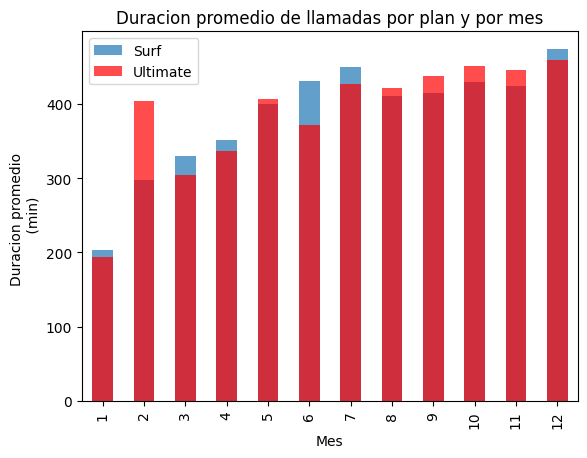

In [34]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

df_nuevo_surf = df_nuevo_final[df_nuevo_final['plan'] == 'surf']
df_nuevo_ultimate = df_nuevo_final[df_nuevo_final['plan'] == 'ultimate']

print('Tamaño de muestra plan surf:', df_nuevo_surf.shape[0])
print('Tamaño de muestra plan ultimate:', df_nuevo_ultimate.shape[0])
print()
print()
df_nuevo_surf.groupby(by='mes')['minutos_totales'].mean().plot(kind='bar', 
                                                               title='Duracion promedio de llamadas por plan y por mes', 
                                                               xlabel= 'mes', ylabel='duracion (min)', label='Surf', alpha=0.7)
df_nuevo_ultimate.groupby(by='mes')['minutos_totales'].mean().plot(kind='bar',
                                                                   title='Duracion promedio de llamadas por plan y por mes', 
                                                                   xlabel= 'Mes', ylabel='Duracion promedio \n (min)', label='Ultimate', alpha=0.7, color='red')
plt.legend()
plt.show()


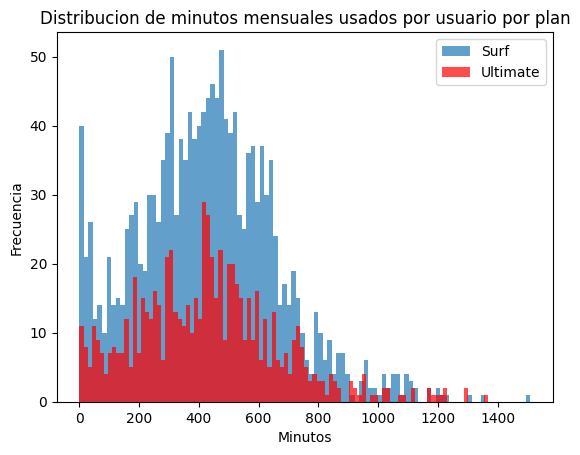

In [35]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

df_nuevo_surf['minutos_totales'].plot(kind='hist', bins=100, label='Surf', alpha=0.7)
df_nuevo_ultimate['minutos_totales'].plot(kind='hist', bins=100, 
                                        label='Ultimate', alpha=0.7, color='red')


plt.title('Distribucion de minutos mensuales usados por usuario por plan')
plt.xlabel('Minutos')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [36]:
# Calcula la media y la varianza de la duración mensual de llamadas.

media_surf = df_nuevo_surf['minutos_totales'].mean()
varianza_surf = df_nuevo_surf['minutos_totales'].var()

media_ultimate = df_nuevo_ultimate['minutos_totales'].mean()
varianza_ultimate = df_nuevo_ultimate['minutos_totales'].var()


print('Media uso de minutos al mes en plan surf:', media_surf.round(2), '(min)')
print('Varianza de uso de minutos al mes en plan surf:', varianza_surf.round(2), '(min)')
print('Media de uso de minutos al mes en plan ultimate:', media_ultimate.round(2), '(min)')
print('Varianza de uso de minutos al mes en plan ultimate:', varianza_ultimate.round(2), '(min)')


Media uso de minutos al mes en plan surf: 428.75 (min)
Varianza de uso de minutos al mes en plan surf: 54968.28 (min)
Media de uso de minutos al mes en plan ultimate: 430.45 (min)
Varianza de uso de minutos al mes en plan ultimate: 57844.46 (min)


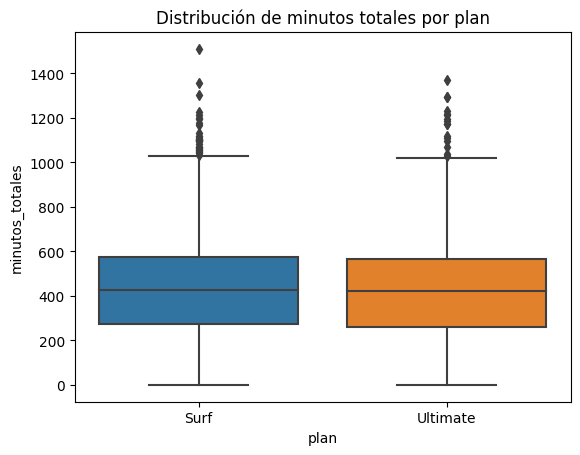

In [37]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
import seaborn as sns

datos_combinados = pd.concat([
    df_nuevo_surf[['minutos_totales']].assign(plan='Surf'),
    df_nuevo_ultimate[['minutos_totales']].assign(plan='Ultimate')
])


sns.boxplot(data=datos_combinados, x='plan', y='minutos_totales')
plt.title('Distribución de minutos totales por plan')
plt.show()



"Antes que nada es importante notar que tenemos una diferencia importante en el tamaño de muestra: el tamaño de la muestra del plan Surf es un poco más del doble que 
del plan Ultimate. Una vez ya dicho eso, no parece haber una diferencia en el comportamiento de los usuarios, ambos tienen una distribución similar y las medidas de posición y dispersión algebraicas (media y varianza respectivamente) de los datos son muy similares. También la mediana y los cuartiles de ambas distribuciones están colocadas de manera muy similar entre ellas. Solo podemos notar que la muestra del plan Ultimate tiene una varianza mayor, lo que parece tener sentido en cuanto los usuarios con este plan tienen un mayor rango de movimiento en su consumo mensual sin tener que acotarse tan estrictamente ante la posibilidad de costo extra."

### Mensajes

Tamaño de muestra plan surf: 1573
Tamaño de muestra plan ultimate: 720




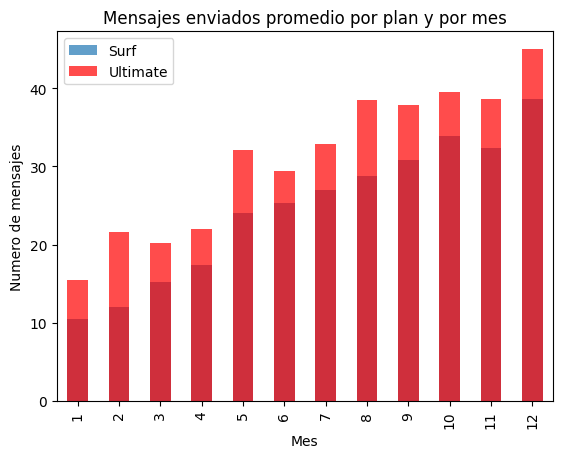

In [38]:
# Compara el promedio de mensajes enviados por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

print('Tamaño de muestra plan surf:', df_nuevo_surf.shape[0])
print('Tamaño de muestra plan ultimate:', df_nuevo_ultimate.shape[0])
print()
print()
df_nuevo_surf.groupby(by='mes')['num_mensajes'].mean().plot(kind='bar', 
                                                               title='Mensajes enviados promedio por plan y por mes', 
                                                               xlabel= 'mes', ylabel='Numero de mensajes', label='Surf', alpha=0.7)
df_nuevo_ultimate.groupby(by='mes')['num_mensajes'].mean().plot(kind='bar', 
                                                                   xlabel= 'Mes', label='Ultimate', alpha=0.7, color='red')
plt.legend()
plt.show()



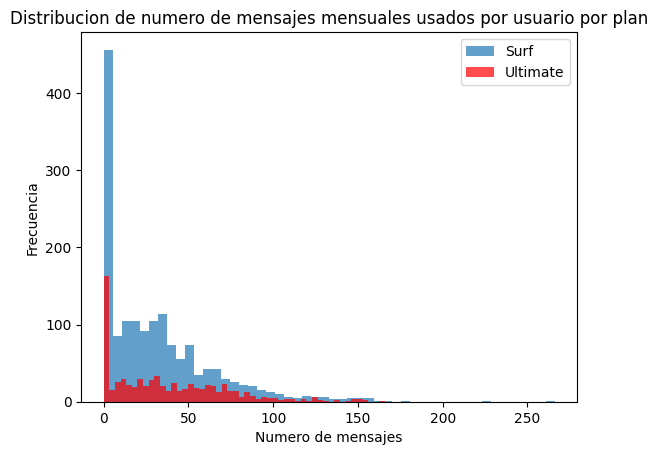

In [39]:
# Distribucion de cantidad de mensajes mensuales por usuario por plan.

df_nuevo_surf['num_mensajes'].plot(kind='hist', bins=50, label='Surf', alpha=0.7)
df_nuevo_ultimate['num_mensajes'].plot(kind='hist', bins=50, 
                                        label='Ultimate', alpha=0.7, color='red')


plt.title('Distribucion de numero de mensajes mensuales usados por usuario por plan')
plt.xlabel('Numero de mensajes')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()



In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.

media_surf = df_nuevo_surf['num_mensajes'].mean()
varianza_surf = df_nuevo_surf['num_mensajes'].var()

media_ultimate = df_nuevo_ultimate['num_mensajes'].mean()
varianza_ultimate = df_nuevo_ultimate['num_mensajes'].var()


print('Media de numero de mensajes usados al mes en plan surf:', media_surf.round(2), '(mensajes)')
print('Varianza de numero de mensajes usados al mes en plan surf:', varianza_surf.round(2), '(mensajes)')
print('Media de numero de mensajes usados al mes en plan ultimate:', media_ultimate.round(2), '(mensajes)')
print('Varianza de numero de mensajes usados al mes en plan ultimate:', varianza_ultimate.round(2), '(mensajes)')


Media de numero de mensajes usados al mes en plan surf: 31.16 (mensajes)
Varianza de numero de mensajes usados al mes en plan surf: 1126.72 (mensajes)
Media de numero de mensajes usados al mes en plan ultimate: 37.55 (mensajes)
Varianza de numero de mensajes usados al mes en plan ultimate: 1208.76 (mensajes)


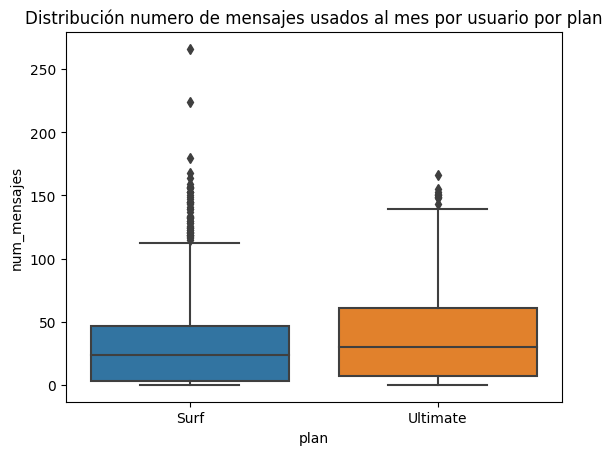

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamada

datos_combinados = pd.concat([
    df_nuevo_surf[['num_mensajes']].assign(plan='Surf'),
    df_nuevo_ultimate[['num_mensajes']].assign(plan='Ultimate')
])


sns.boxplot(data=datos_combinados, x='plan', y='num_mensajes')
plt.title('Distribución numero de mensajes usados al mes por usuario por plan')
plt.show()


"Resulta que parece ser que en términos de número de mensajes enviados por usuario al mes si hay algún tipo de diferencia en el comportamiento entre los usuarios del plan surf y los del plan ultimate. En primer lugar, en promedio los usuarios del plan ultimate superan en uso de mensajes al usuario del plan surf, aunque revisando los histogramas esto se puede deber a que en el histograma del plan surf vemos que hay una mayor cantidad de usuarios que no enviaron ningún mensaje, por lo que esto pudo haber sido la razón por la que en el promedio el plan ultimate terminara superando al plan surf en todos los meses. En las medidas de posición y de dispersión estructurales y algebraicas parece si haber algún tipo de diferencia, por lo menos más que en el análisis de las llamadas. Algo interesante a notar es que, en término de número de mensajes usados al mes, la muestra del plan surf parece tener una mayor cantidad de valores atípicos."

### Internet

Tamaño de muestra plan surf: 1573
Tamaño de muestra plan ultimate: 720




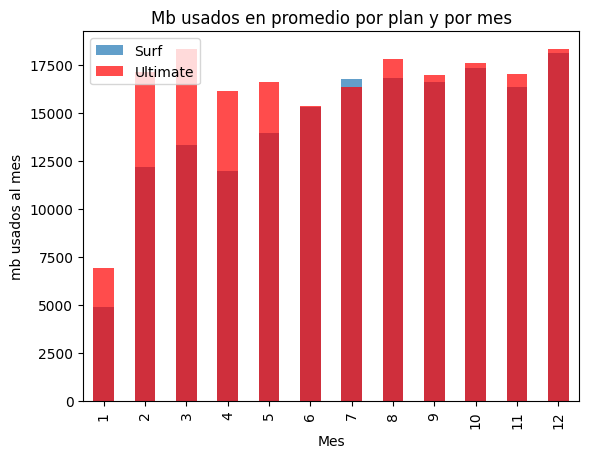

In [ ]:
# Compara el promedio de mb usados por los usuarios por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

print('Tamaño de muestra plan surf:', df_nuevo_surf.shape[0])
print('Tamaño de muestra plan ultimate:', df_nuevo_ultimate.shape[0])
print()
print()
df_nuevo_surf.groupby(by='mes')['mb_internet'].mean().plot(kind='bar', 
                                                               title='Mb usados en promedio por plan y por mes', 
                                                               xlabel= 'mes', ylabel='mb usados al mes', label='Surf', alpha=0.7)
df_nuevo_ultimate.groupby(by='mes')['mb_internet'].mean().plot(kind='bar', 
                                                                   xlabel= 'Mes', label='Ultimate', alpha=0.7, color='red')
plt.legend()
plt.show()


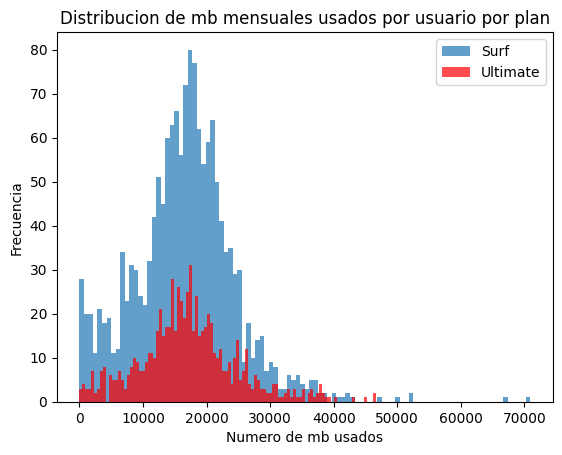

In [43]:
# Distribucion de mb mensuales por usuario por plan.


df_nuevo_surf['mb_internet'].plot(kind='hist', bins=100, label='Surf', alpha=0.7)
df_nuevo_ultimate['mb_internet'].plot(kind='hist', bins=100, 
                                        label='Ultimate', alpha=0.7, color='red')


plt.title('Distribucion de mb mensuales usados por usuario por plan')
plt.xlabel('Numero de mb usados')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [ ]:
# Calcula la media y la varianza de los mb mensuales.

media_surf = df_nuevo_surf['mb_internet'].mean()
varianza_surf = df_nuevo_surf['mb_internet'].var()

media_ultimate = df_nuevo_ultimate['mb_internet'].mean()
varianza_ultimate = df_nuevo_ultimate['mb_internet'].var()


print('Media de numero de mb usados al mes en plan surf:', media_surf.round(2), '(mb)')
print('Varianza de numero de mb usados al mes en plan surf:', varianza_surf.round(2), '(mb)')
print('Media de numero de mb usados al mes en plan ultimate:', media_ultimate.round(2), '(mb)')
print('Varianza de numero de mb usados al mes en plan ultimate:', varianza_ultimate.round(2), '(mb)')


Media de numero de mb usados al mes en plan surf: 16558.28 (mb)
Varianza de numero de mb usados al mes en plan surf: 64216395.84 (mb)
Media de numero de mb usados al mes en plan ultimate: 17214.7 (mb)
Varianza de numero de mb usados al mes en plan ultimate: 61652293.32 (mb)


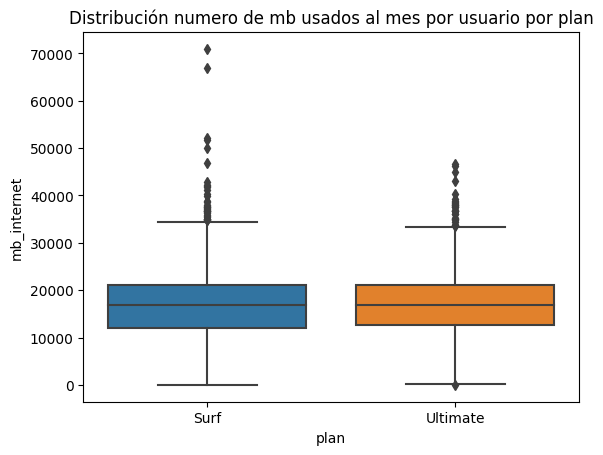

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamada

datos_combinados = pd.concat([
    df_nuevo_surf[['mb_internet']].assign(plan='Surf'),
    df_nuevo_ultimate[['mb_internet']].assign(plan='Ultimate')
])


sns.boxplot(data=datos_combinados, x='plan', y='mb_internet')
plt.title('Distribución numero de mb usados al mes por usuario por plan')
plt.show()


"Tenemos la misma situación, no parece haber diferencias tan importantes en el comportamiento de los usuarios dependiendo el plan que hayan contratado."

## Ingreso

Tamaño de muestra plan surf: 1573
Tamaño de muestra plan ultimate: 720




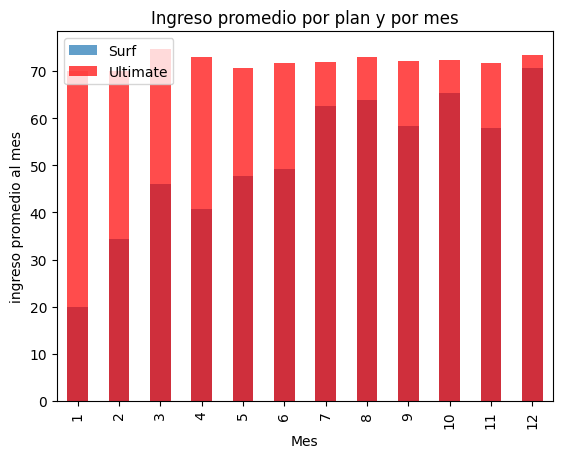

In [ ]:
# Compara el promedio de mb usados por los usuarios por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

print('Tamaño de muestra plan surf:', df_nuevo_surf.shape[0])
print('Tamaño de muestra plan ultimate:', df_nuevo_ultimate.shape[0])
print()
print()
df_nuevo_surf.groupby(by='mes')['ingreso_mes'].mean().plot(kind='bar', 
                                                               title='Ingreso promedio por plan y por mes', 
                                                               xlabel= 'Mes', ylabel='ingreso promedio al mes', label='Surf', alpha=0.7)
df_nuevo_ultimate.groupby(by='mes')['ingreso_mes'].mean().plot(kind='bar', 
                                                                   xlabel= 'Mes', label='Ultimate', alpha=0.7, color='red')
plt.legend()
plt.show()


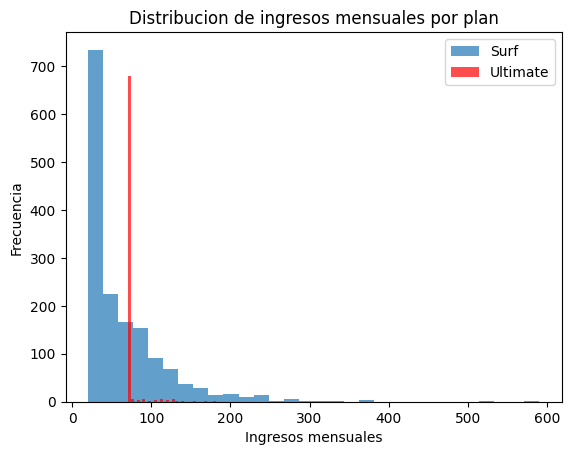

In [ ]:
# Distribucion de mb mensuales por usuario por plan.

df_nuevo_surf['ingreso_mes'].plot(kind='hist', bins=30, label='Surf', alpha=0.7)
df_nuevo_ultimate['ingreso_mes'].plot(kind='hist', bins=30, 
                                        label='Ultimate', alpha=0.7, color='red')


plt.title('Distribucion de ingresos mensuales por plan')
plt.xlabel('Ingresos mensuales')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


In [ ]:
media_surf = df_nuevo_surf['ingreso_mes'].mean()
varianza_surf = df_nuevo_surf['ingreso_mes'].var()

media_ultimate = df_nuevo_ultimate['ingreso_mes'].mean()
varianza_ultimate = df_nuevo_ultimate['ingreso_mes'].var()


print('Media de ingresos mensuales en plan surf:', media_surf.round(2), '(usd)')
print('Varianza de ingresos mensuales en plan surf:', varianza_surf.round(2), '(usd)')
print('Media de ingresos mensuales en plan ultimate:', media_ultimate.round(2), '(usd)')
print('Varianza de ingresos mensualesen plan ultimate:', varianza_ultimate.round(2), '(usd)')


Media de ingresos mensuales en plan surf: 60.71 (usd)
Varianza de ingresos mensuales en plan surf: 3067.84 (usd)
Media de ingresos mensuales en plan ultimate: 72.31 (usd)
Varianza de ingresos mensualesen plan ultimate: 129.85 (usd)


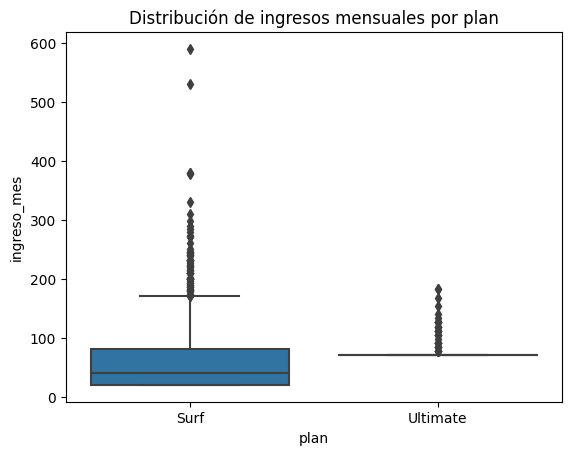

In [ ]:
datos_combinados = pd.concat([
    df_nuevo_surf[['ingreso_mes']].assign(plan='Surf'),
    df_nuevo_ultimate[['ingreso_mes']].assign(plan='Ultimate')
])


sns.boxplot(data=datos_combinados, x='plan', y='ingreso_mes')
plt.title('Distribución de ingresos mensuales por plan')
plt.show()


"Vayamos analizando por partes. Parece ser que en promedio los ingresos mensuales del plan ultimate se mantienen estables y en un mismo nivel a lo largo de todo el año, mientras que en promedio los ingreso mensuales del plan surf van aumentando hasta llegar a su máximo al final del año. Esto se puede explicar debido a que como el plan ultimate ofrece más llamadas, mensajes y MB, entonces los usuarios no suelen tener cargos extra y así el ingreso primordialmente proviene de la tarifa del plan. Esto lo podemos corroborar si vemos las distribuciones, ya que podemos ver que la distribución del plan ultimate vemos un pico de frecuencia de más de 600 usuarios, siendo la muestra del plan ultimate de un tamaño de 720. También en la distribución del plan surf podemos observar que aunque también presenta un pico alrededor del precio de su tarifa, su variabilidad es mucho mayor, llegando incluso a haber usuarios con tarifas mensuales mucho más altas a las de los usuarios de la tarifa ultimate. Esto se corrobora con las medidas de posición y dispersión algebraicas donde la media del plan ultimate está muy cercano al precio de su tarifa y además su varianza es muy pequeña. Esto también se observa en las medianas y los cuartiles de ambos grupos, ya que el plan ultimate tiene una distancia intercuartílica muy pequeña."

## Prueba las hipótesis estadísticas

Vamos a hacer una prueba de hipótesis donde nuestra hipótesis nula es que no existe una diferencia estadísticamente significativa entre los ingresos provenientes del plan surf a los provenientes del plan ultimate. La hipótesis alternativa es que sí existe una diferencia estadísticamente significativa. Formalmente, estaría expresado de la siguiente manera:


H0 = No existe una diferencia real entre las poblaciones de usuarios del plan Ultimate con los del plan Surf; la diferencia observada entre las medias muestrales se debe únicamente al error de muestreo (azar).


H1 = Existe una diferencia significativa entre las poblaciones de usuarios del plan Ultimate con los del plan Surf; es altamente improbable que la diferencia observada haya ocurrido por puro azar bajo el supuesto de una distribución común.


Nuestro nivel de signigficancia alpha: 0.05

In [50]:
# Prueba las hipótesis

ingresos_surf = df_nuevo_surf['ingreso_mes']
ingresos_ultimate = df_nuevo_ultimate['ingreso_mes']

alpha = 0.05

results = st.ttest_ind(ingresos_surf, ingresos_ultimate, equal_var=False)

print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos H0')
else:
    print('No podemos rechazar H0')



Valor p: 3.1703905481135734e-15
Rechazamos H0


Ahora mostraremos que los usuarios que viven en NY-NJ existe una diferencia significativa en su comportamiento, en cuanto a ingresos para la empresa, comparado
contra los usuarios de otros estados. Para esto no se filtra por mes ni por plan.


H0 = No existe una diferencia real entre las poblaciones; la diferencia observada entre las medias muestrales se debe únicamente al error de muestreo (azar).


H1 = Existe una diferencia significativa entre las poblaciones; es altamente improbable que la diferencia observada haya ocurrido por puro azar bajo el supuesto de una distribución común.

In [ ]:
print(df_users.sample(20))


     user_id first_name last_name  age  \
51      1051    Rosario     Gibbs   55   
488     1488    Shirley     Jones   29   
55      1055    Patrick    Mclean   52   
470     1470     Gerald     Reese   45   
417     1417      Jorge    Madden   51   
83      1083     Lyndia   Acevedo   65   
356     1356        Hae      Ryan   46   
136     1136     Jasper  Caldwell   25   
141     1141    Kirstie    Hodges   46   
123     1123    Dierdre      Nash   66   
288     1288    Jenette      Rush   60   
226     1226     Denver   Harrell   64   
230     1230      Andre     Estes   38   
12      1012    Jonelle   Mcbride   59   
448     1448     Elayne     Foley   33   
50      1050       Jone      Owen   23   
222     1222       Cleo  Anderson   18   
355     1355      Digna     Tyson   57   
365     1365    Milford      Rush   19   
173     1173    Tristan      Cain   27   

                                                 city   reg_date      plan  \
51             San Diego-Chula Vista-Ca

In [ ]:
#crear nuevas columnas categoricas

def clasificar_area(city):
    return 'NY-NJ' if 'New York-Newark-Jersey City' in str(city) else 'Otras'

df_nuevo_surf_area = df_nuevo_surf.merge(
    df_users[['user_id', 'city']], on='user_id', how='left'
).assign(
    area=lambda x: x['city'].apply(clasificar_area)
)

df_nuevo_ultimate_area = df_nuevo_ultimate.merge(
   df_users[['user_id', 'city']], on='user_id', how='left'
).assign(
    area=lambda x: x['city'].apply(clasificar_area)
)

df_nuevo_completo_area = pd.concat([df_nuevo_surf_area, df_nuevo_ultimate_area])


print(df_nuevo_surf_area.sample(5))
print('Tamaño del data frame df_nuevo_surf_area', df_nuevo_surf_area.shape[0])
print()
print()
print()
print(df_nuevo_ultimate_area.sample(5))
print('Tamaño del data frame df_nuevo_ultimate_area', df_nuevo_ultimate_area.shape[0])
print()
print()
print()
print(df_nuevo_ultimate_area.sample(5))
print('Tamaño del data frame df_nuevo_completo_area', df_nuevo_completo_area.shape[0])


      user_id  mes  num_llamadas  minutos_totales  num_mensajes  mb_internet  \
906      1280   12          84.0            610.0          55.0     17784.34   
144      1054   12          60.0            461.0          37.0     22992.69   
1216     1364    9          65.0            446.0          22.0     14818.32   
477      1145    8          46.0            311.0          75.0     17008.20   
1414     1437   11          60.0            467.0           0.0     15189.99   

      plan  ingreso_mes                                       city   area  
906   surf        53.45  New York-Newark-Jersey City, NY-NJ-PA MSA  NY-NJ  
144   surf       100.00              Phoenix-Mesa-Chandler, AZ MSA  Otras  
1216  surf        20.00     San Diego-Chula Vista-Carlsbad, CA MSA  Otras  
477   surf        40.75     San Jose-Sunnyvale-Santa Clara, CA MSA  Otras  
1414  surf        20.00        Dallas-Fort Worth-Arlington, TX MSA  Otras  
Tamaño del data frame df_nuevo_surf_area 1573



     user_id  

Valor p: 0.0335256158853001
Rechazamos H0


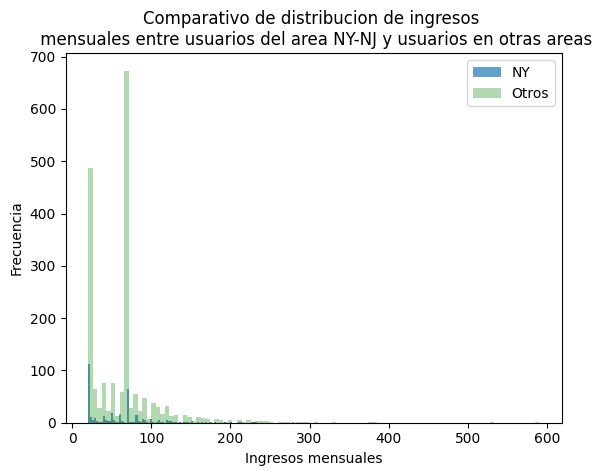

In [53]:
#filtrar el data frame por area NY-NJ u Otra y pruebas de hipotesis

df_nuevo_completo_area_ny = df_nuevo_completo_area[df_nuevo_completo_area['area'] == 'NY-NJ']
df_nuevo_completo_area_otras = df_nuevo_completo_area[~(df_nuevo_completo_area['area'] == 'NY-NJ')]




ingresos_ny = df_nuevo_completo_area_ny['ingreso_mes']
ingresos_otros = df_nuevo_completo_area_otras['ingreso_mes']

alpha = 0.05

results = st.ttest_ind(ingresos_ny, ingresos_otros, equal_var=False)

print('Valor p:', results.pvalue)

if (results.pvalue < alpha):
    print('Rechazamos H0')
else:
    print('No podemos rechazar H0')


ingresos_ny.plot(kind='hist', bins=100, label='NY', alpha=0.7)
ingresos_otros.plot(kind='hist', bins=100, 
                                        label='Otros', alpha=0.3, color='green')


plt.title('Comparativo de distribucion de ingresos \n mensuales entre usuarios del area NY-NJ y usuarios en otras areas')
plt.xlabel('Ingresos mensuales')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


## Conclusión general

"Muy buen proyecto. Se logró un preprocesamiento de los datos, se crearon nuevas variables y se generaron estadísticas para estas nuevas variables que nos permitieron estudiar el comportamiento de los usuarios de un plan contra los del otro. En general nos enfocamos en intentar observar diferencias entre planes y entre meses, logrando al final observar una diferencia estadísticamente significativa entre el ingreso que aporta a la empresa el plan surf y el ingreso del plan ultimate, pudiendo afirmar con confianza que la diferencia que existe entre las medias de las dos muestras no es un evento muy raro dentro de una misma distribución poblacional, sino que se debe a diferencias en las medias de dos poblaciones estadisticas distintas."

